# 04 — Modeling and Forecast Generation

This notebook trains and evaluates multi-output regression models for medium-range weather forecasting.

The notebook uses the model-ready table stored in DuckDB:

`analytics.model_features`

The final output is a hybrid 28-day forecast:

- Days 1–7: Open-Meteo API forecast
- Days 8–28: ML model forecast

The final forecast is stored in DuckDB as:

`analytics.final_28d_forecast`

## 1. Imports & Setup


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.db import run_query, get_connection
from src.features import (
    get_feature_columns,
    get_target_columns,
    build_features,
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Model-Ready Data


In [2]:
df = run_query("SELECT * FROM analytics.model_features").copy()

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time"].min(), "→", df["time"].max())
print("Cities:", df["city"].unique())

df.head()

Shape: (10925, 44)
Date range: 2020-05-04 00:00:00 → 2026-04-27 00:00:00
Cities: ['Baku' 'Gabala' 'Guba' 'Lankaran' 'Shaki']


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,...,wind_7d_avg,humidity_7d_avg,humidity_14d_avg,cloud_cover_7d_avg,rainy_days_7d,temperature_trend_1d,humidity_trend_1d,wind_trend_1d,precipitation_trend_1d,city_encoded
0,2020-05-04,22.5,0.0,23.3,76,43,22.3,46191.04,Baku,5,...,22.728571,77.285714,77.285714,45.428571,1.0,-0.4,-5.0,8.4,-1.3,0
1,2020-05-05,25.8,0.0,21.6,62,85,24.7,33037.54,Baku,5,...,23.785714,77.000000,77.125000,47.857143,1.0,3.3,-14.0,-1.7,0.0,0
2,2020-05-06,24.4,1.4,21.9,71,82,27.1,17816.28,Baku,5,...,20.871429,74.000000,75.444444,49.857143,1.0,-1.4,9.0,0.3,1.4,0
3,2020-05-07,17.8,16.6,25.8,89,98,17.7,7495.00,Baku,5,...,20.800000,75.428571,75.000000,54.428571,2.0,-6.6,18.0,3.9,15.2,0
4,2020-05-08,22.2,14.1,18.0,78,60,23.9,35270.89,Baku,5,...,21.200000,77.142857,76.272727,61.285714,3.0,4.4,-11.0,-7.8,-2.5,0


## 3. Create Horizon-Aware Supervised Dataset


### 3.1 — supervised dataset

In [3]:
def make_supervised(df_input: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """
    Create supervised dataset for a specific forecast horizon.

    time = origin date
    target_time = date being predicted
    target columns = weather values at target_time
    """
    out = df_input.copy().sort_values(["city", "time"]).reset_index(drop=True)

    out["target_time"] = out.groupby("city")["time"].shift(-horizon)

    for col in get_target_columns():
        out[f"{col}_target"] = out.groupby("city")[col].shift(-horizon)

    out = out.dropna().reset_index(drop=True)

    out["target_month"] = out["target_time"].dt.month
    out["target_day_of_month"] = out["target_time"].dt.day
    out["target_day_of_year"] = out["target_time"].dt.dayofyear

    out["target_day_sin"] = np.sin(2 * np.pi * out["target_day_of_year"] / 365.25)
    out["target_day_cos"] = np.cos(2 * np.pi * out["target_day_of_year"] / 365.25)

    return out

In [4]:
def evaluate_multitarget(y_true: pd.DataFrame, y_pred: np.ndarray, target_names):
    rows = []

    for i, target in enumerate(target_names):
        yt = y_true.iloc[:, i]
        yp = y_pred[:, i]

        rows.append({
            "target": target,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
        })

    return pd.DataFrame(rows)

### 3.2 — features

In [5]:
base_feature_cols = get_feature_columns()

horizon_feature_cols = base_feature_cols + [
    "target_month",
    "target_day_of_month",
    "target_day_of_year",
    "target_day_sin",
    "target_day_cos",
]

target_cols = get_target_columns()
horizon_target_cols = [f"{col}_target" for col in target_cols]

print("Base features:", len(base_feature_cols))
print("Horizon-aware features:", len(horizon_feature_cols))
print("Targets:", target_cols)

Base features: 35
Horizon-aware features: 40
Targets: ['temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean', 'cloud_cover_mean']


## 4. Define Evaluation Metrics


In [6]:
def evaluate_multitarget(
    y_true: pd.DataFrame,
    y_pred: np.ndarray,
    target_names: list[str],
) -> pd.DataFrame:
    """
    Evaluate multi-output regression predictions target by target.
    """
    rows = []

    for i, target in enumerate(target_names):
        actual = y_true.iloc[:, i]
        predicted = y_pred[:, i]

        rows.append({
            "target": target,
            "MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            "R2": r2_score(actual, predicted),
        })

    return pd.DataFrame(rows)

## 5. Define Candidate Models


In [7]:
models = {
    "Dummy": MultiOutputRegressor(
        DummyRegressor(strategy="mean")
    ),

    "Ridge": MultiOutputRegressor(
        Ridge(alpha=1.0)
    ),

    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    ),

    "ExtraTrees": MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    ),

    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(random_state=42)
    ),

    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )
    ),
}

## 6. Backtest Models

Backtesting evaluates how the models would have performed on recent historical data.

We use a time-based split because forecasting models must learn from the past and predict the future.

### 6.1 — experiment function

In [8]:
def run_horizon_experiment(
    df_input: pd.DataFrame,
    horizon: int,
    split_date: str,
):
    """
    Train and evaluate all candidate models for a forecast horizon.
    """
    supervised_df = make_supervised(df_input, horizon=horizon)

    train_df = supervised_df[supervised_df["time"] < split_date].copy()
    test_df = supervised_df[supervised_df["time"] >= split_date].copy()

    X_train = train_df[horizon_feature_cols]
    y_train = train_df[horizon_target_cols]

    X_test = test_df[horizon_feature_cols]
    y_test = test_df[horizon_target_cols]

    overall_results = []
    target_results = {}
    predictions = {}

    for model_name, model_template in models.items():
        print(f"Training {model_name} for horizon={horizon}...")

        model = clone(model_template)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        predictions[model_name] = preds

        per_target = evaluate_multitarget(
            y_true=y_test,
            y_pred=preds,
            target_names=horizon_target_cols,
        )

        target_results[model_name] = per_target

        overall_results.append({
            "model": model_name,
            "horizon": horizon,
            "MAE": per_target["MAE"].mean(),
            "RMSE": per_target["RMSE"].mean(),
            "R2": per_target["R2"].mean(),
        })

    results_df = (
        pd.DataFrame(overall_results)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    return supervised_df, test_df, y_test, predictions, results_df, target_results

### 6.2 — run experiments

In [9]:
split_date = "2025-01-01"

df_7d, test_7d, y_test_7d, preds_7d, results_7d, target_results_7d = run_horizon_experiment(
    df_input=df,
    horizon=7,
    split_date=split_date,
)

df_28d, test_28d, y_test_28d, preds_28d, results_28d, target_results_28d = run_horizon_experiment(
    df_input=df,
    horizon=28,
    split_date=split_date,
)

print("7-day backtest results")
display(results_7d)

print("28-day backtest results")
display(results_28d)

Training Dummy for horizon=7...
Training Ridge for horizon=7...
Training RandomForest for horizon=7...
Training ExtraTrees for horizon=7...
Training GradientBoosting for horizon=7...
Training XGBoost for horizon=7...
Training Dummy for horizon=28...
Training Ridge for horizon=28...
Training RandomForest for horizon=28...
Training ExtraTrees for horizon=28...
Training GradientBoosting for horizon=28...
Training XGBoost for horizon=28...
7-day backtest results


,model,horizon,MAE,RMSE,R2
0,Ridge,7,9.230948,11.661397,0.298342
1,GradientBoosting,7,9.166832,11.675268,0.286030
2,RandomForest,7,9.512294,12.119222,0.224805
3,XGBoost,7,9.425215,12.131438,0.230592
4,ExtraTrees,7,9.566187,12.194415,0.227101
5,Dummy,7,11.711235,14.240737,-0.036429


28-day backtest results


,model,horizon,MAE,RMSE,R2
0,GradientBoosting,28,9.194388,11.727853,0.286167
1,Ridge,28,9.475984,11.960089,0.266173
2,RandomForest,28,9.578194,12.157482,0.225907
3,ExtraTrees,28,9.565472,12.180945,0.225590
4,XGBoost,28,9.465727,12.184541,0.227484
5,Dummy,28,11.616975,14.189631,-0.023521


## 7. Select Final Model

In [10]:
best_7d_name = results_7d.iloc[0]["model"]
best_28d_name = results_28d.iloc[0]["model"]

final_model_name = best_28d_name

print("Best 7-day model:", best_7d_name)
print("Best 28-day model:", best_28d_name)
print("Final selected model:", final_model_name)

Best 7-day model: Ridge
Best 28-day model: GradientBoosting
Final selected model: GradientBoosting


The final model is selected using the 28-day backtest result because the project goal is medium-range forecasting up to 28 days.

The main selection metric is average RMSE across all five target variables.

## 8. Per-Target Model Performance

In [11]:
per_target_28d = target_results_28d[final_model_name].copy()

display(per_target_28d)

,target,MAE,RMSE,R2
0,temperature_2m_max_target,3.438848,4.501661,0.770403
1,precipitation_sum_target,2.705378,6.088893,-0.001514
2,wind_speed_10m_max_target,4.543068,5.820140,0.106644
3,relative_humidity_2m_mean_target,9.314592,11.595824,0.369449
4,cloud_cover_mean_target,25.970052,30.632748,0.185850


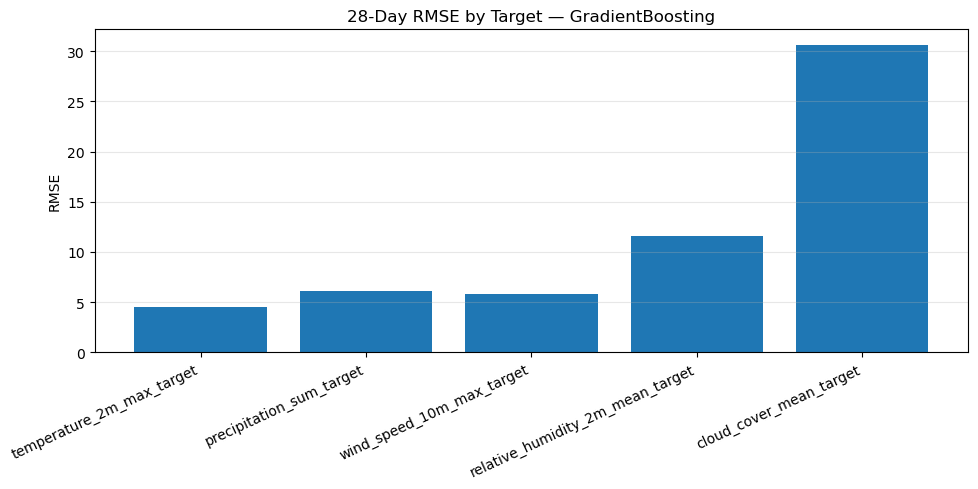

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    per_target_28d["target"],
    per_target_28d["RMSE"],
)

plt.title(f"28-Day RMSE by Target — {final_model_name}")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "model_rmse_by_target_28d.png", dpi=150, bbox_inches="tight")
plt.show()

The per-target metrics show which weather variables are easier or harder to predict.

Temperature is usually more predictable because it has strong seasonal patterns. Precipitation and cloud cover are usually harder because they are more irregular and event-driven.

## 9. Feature Importance Analysis

### 9.1 — importance function

In [13]:
def get_multioutput_feature_importance(
    model: MultiOutputRegressor,
    feature_names: list[str],
) -> pd.DataFrame:
    """
    Average feature importance across target-specific estimators.
    Works for tree-based models wrapped in MultiOutputRegressor.
    """
    importances = []

    for estimator in model.estimators_:
        if hasattr(estimator, "feature_importances_"):
            importances.append(estimator.feature_importances_)

    if not importances:
        raise ValueError("This model does not expose feature_importances_.")

    mean_importance = np.mean(importances, axis=0)

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": mean_importance,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

### 9.2 — train final model for importance

In [14]:
df_sup_28 = make_supervised(df, horizon=28)

train_28 = df_sup_28[df_sup_28["time"] < split_date].copy()

X_train_28 = train_28[horizon_feature_cols]
y_train_28 = train_28[horizon_target_cols]

final_backtest_model = clone(models[final_model_name])
final_backtest_model.fit(X_train_28, y_train_28)

importance_28 = get_multioutput_feature_importance(
    model=final_backtest_model,
    feature_names=horizon_feature_cols,
)

importance_28.head(20)

,feature,importance
0,day_cos,0.300979
1,city_encoded,0.192101
2,target_day_cos,0.135037
3,wind_7d_avg,0.043872
4,humidity_14d_avg,0.028928
5,target_day_sin,0.028174
6,temperature_14d_avg,0.022195
7,day_sin,0.018845
8,target_day_of_year,0.015574
9,comfort_gap,0.014750


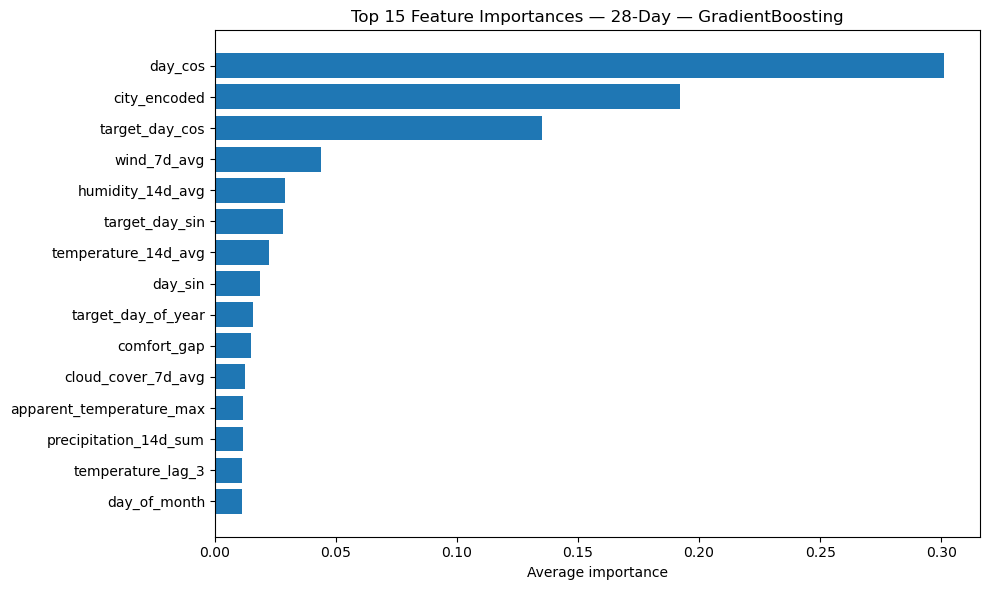

In [15]:
top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    importance_28.head(top_n)["feature"][::-1],
    importance_28.head(top_n)["importance"][::-1],
)

plt.title(f"Top {top_n} Feature Importances — 28-Day — {final_model_name}")
plt.xlabel("Average importance")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_importance_28d.png", dpi=150, bbox_inches="tight")
plt.show()

Feature importance helps explain what the final model relies on.

Seasonality features, city encoding, and rolling weather trends are expected to be important because weather strongly depends on the time of year, location, and recent atmospheric conditions.

## 10. Prepare Latest Forecast Base

The final forecast uses a hybrid strategy.

First, we use the 7-day Open-Meteo forecast directly. Then we combine historical data with this 7-day forecast to create the latest feature rows for each city. These rows become the starting point for ML predictions for days 8–28.

## 8.1 — load forecast

In [16]:
forecast_df = run_query("SELECT * FROM raw.forecast").copy()
forecast_df["time"] = pd.to_datetime(forecast_df["time"])
forecast_df = forecast_df.sort_values(["city", "time"]).reset_index(drop=True)

print(forecast_df.shape)
print(forecast_df["time"].min(), "→", forecast_df["time"].max())
forecast_df.head()

(35, 9)
2026-04-28 00:00:00 → 2026-05-04 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city
0,2026-04-28,14.1,0.0,45.2,52,90,7.1,31968.01,Baku
1,2026-04-29,14.3,0.0,22.1,63,96,10.5,15011.54,Baku
2,2026-04-30,17.7,0.0,19.1,59,42,15.3,42871.36,Baku
3,2026-05-01,18.0,0.0,31.0,76,20,14.7,48670.33,Baku
4,2026-05-02,19.2,0.0,32.3,80,63,16.6,46724.45,Baku


## 8.2 — combine historical + forecast

In [17]:
historical_raw = run_query("SELECT * FROM raw.historical").copy()
historical_raw["time"] = pd.to_datetime(historical_raw["time"])

forecast_raw = run_query("SELECT * FROM raw.forecast").copy()
forecast_raw["time"] = pd.to_datetime(forecast_raw["time"])

combined_for_future = pd.concat(
    [historical_raw, forecast_raw],
    ignore_index=True
)

combined_for_future = (
    combined_for_future
    .sort_values(["city", "time"])
    .drop_duplicates(subset=["city", "time"], keep="last")
    .reset_index(drop=True)
)

future_feature_df, future_le = build_features(combined_for_future)

latest_origin = (
    future_feature_df
    .sort_values(["city", "time"])
    .groupby("city")
    .tail(1)
    .reset_index(drop=True)
)

latest_origin[["city", "time"]]

,city,time
0,Baku,2026-05-04
1,Gabala,2026-05-04
2,Guba,2026-05-04
3,Lankaran,2026-05-04
4,Shaki,2026-05-04


### 10.1 — Load forecast

In [18]:
forecast_df = run_query("SELECT * FROM raw.forecast").copy()

forecast_df["time"] = pd.to_datetime(forecast_df["time"])
forecast_df = forecast_df.sort_values(["city", "time"]).reset_index(drop=True)

print("Forecast shape:", forecast_df.shape)
print("Forecast date range:", forecast_df["time"].min(), "→", forecast_df["time"].max())

forecast_df.head()

Forecast shape: (35, 9)
Forecast date range: 2026-04-28 00:00:00 → 2026-05-04 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city
0,2026-04-28,14.1,0.0,45.2,52,90,7.1,31968.01,Baku
1,2026-04-29,14.3,0.0,22.1,63,96,10.5,15011.54,Baku
2,2026-04-30,17.7,0.0,19.1,59,42,15.3,42871.36,Baku
3,2026-05-01,18.0,0.0,31.0,76,20,14.7,48670.33,Baku
4,2026-05-02,19.2,0.0,32.3,80,63,16.6,46724.45,Baku


### 10.2 — Combine historical 

In [19]:
historical_raw = run_query("SELECT * FROM raw.historical").copy()
forecast_raw = run_query("SELECT * FROM raw.forecast").copy()

historical_raw["time"] = pd.to_datetime(historical_raw["time"])
forecast_raw["time"] = pd.to_datetime(forecast_raw["time"])

combined_for_future = pd.concat(
    [historical_raw, forecast_raw],
    ignore_index=True,
)

combined_for_future = (
    combined_for_future
    .sort_values(["city", "time"])
    .drop_duplicates(subset=["city", "time"], keep="last")
    .reset_index(drop=True)
)

future_feature_df, _ = build_features(combined_for_future)

latest_origin = (
    future_feature_df
    .sort_values(["city", "time"])
    .groupby("city")
    .tail(1)
    .reset_index(drop=True)
)

latest_origin[["city", "time"]]

,city,time
0,Baku,2026-05-04
1,Gabala,2026-05-04
2,Guba,2026-05-04
3,Lankaran,2026-05-04
4,Shaki,2026-05-04


## 11. Build Final 28-Day Hybrid Forecast

### 11.1 — Prepare API forecast

In [20]:
def prepare_api_forecast_output(forecast_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare Open-Meteo forecast as days 1-7 of the final 28-day forecast.
    """
    api_part = forecast_df.copy()
    api_part = api_part.sort_values(["city", "time"]).reset_index(drop=True)

    api_part["origin_time"] = (
        api_part.groupby("city")["time"].transform("min")
        - pd.Timedelta(days=1)
    )

    api_part["forecast_horizon"] = api_part.groupby("city").cumcount() + 1
    api_part["target_time"] = api_part["time"]
    api_part["source"] = "api_forecast"

    output_cols = [
        "city",
        "origin_time",
        "forecast_horizon",
        "target_time",
        "source",
    ] + target_cols

    return api_part[output_cols]

### 11.2 — Train direct horizon models

In [21]:
def train_direct_horizon_models(
    df_input: pd.DataFrame,
    horizons: list[int],
    model_name: str,
) -> dict[int, MultiOutputRegressor]:
    """
    Train one model per horizon.

    Horizon 1 after the API forecast corresponds to final forecast day 8.
    Horizon 21 after the API forecast corresponds to final forecast day 28.
    """
    trained_models = {}

    for horizon in horizons:
        print(f"Training {model_name} for ML horizon={horizon}...")

        supervised_df = make_supervised(df_input, horizon=horizon)

        X_train = supervised_df[horizon_feature_cols]
        y_train = supervised_df[horizon_target_cols]

        model = clone(models[model_name])
        model.fit(X_train, y_train)

        trained_models[horizon] = model

    return trained_models

### 11.3 — Predict ml days after API

In [22]:
def predict_ml_days_after_api(
    latest_origin_df: pd.DataFrame,
    training_df: pd.DataFrame,
    model_name: str,
    ml_days: int = 21,
) -> pd.DataFrame:
    """
    Predict days 8-28 of the final forecast.

    API covers days 1-7.
    ML model covers the remaining 21 days.
    """
    horizons = list(range(1, ml_days + 1))

    direct_models = train_direct_horizon_models(
        df_input=training_df,
        horizons=horizons,
        model_name=model_name,
    )

    rows = []

    for _, origin_row in latest_origin_df.iterrows():
        city = origin_row["city"]
        origin_time = pd.to_datetime(origin_row["time"])

        for horizon in horizons:
            target_time = origin_time + pd.Timedelta(days=horizon)

            row = origin_row.copy()
            row["target_time"] = target_time
            row["target_month"] = target_time.month
            row["target_day_of_month"] = target_time.day
            row["target_day_of_year"] = target_time.dayofyear
            row["target_day_sin"] = np.sin(2 * np.pi * target_time.dayofyear / 365.25)
            row["target_day_cos"] = np.cos(2 * np.pi * target_time.dayofyear / 365.25)

            X_future = pd.DataFrame([row])[horizon_feature_cols]
            pred = direct_models[horizon].predict(X_future)[0]

            result = {
                "city": city,
                "origin_time": origin_time,
                "forecast_horizon": horizon + 7,
                "target_time": target_time,
                "source": "ml_model",
            }

            for i, target in enumerate(target_cols):
                result[target] = pred[i]

            rows.append(result)

    return pd.DataFrame(rows)

### 11.4 — Build final forecast

In [23]:
api_7d = prepare_api_forecast_output(forecast_df)

ml_21d = predict_ml_days_after_api(
    latest_origin_df=latest_origin,
    training_df=df,
    model_name=final_model_name,
    ml_days=21,
)

final_28d_forecast = (
    pd.concat([api_7d, ml_21d], ignore_index=True)
    .sort_values(["city", "target_time"])
    .reset_index(drop=True)
)

print("Final forecast date range:")
print(final_28d_forecast["target_time"].min(), "→", final_28d_forecast["target_time"].max())

print("\nRows by city and source:")
display(
    final_28d_forecast
    .groupby(["city", "source"])
    .size()
    .reset_index(name="rows")
)

final_28d_forecast.head(35)

Training GradientBoosting for ML horizon=1...
Training GradientBoosting for ML horizon=2...
Training GradientBoosting for ML horizon=3...
Training GradientBoosting for ML horizon=4...
Training GradientBoosting for ML horizon=5...
Training GradientBoosting for ML horizon=6...
Training GradientBoosting for ML horizon=7...
Training GradientBoosting for ML horizon=8...
Training GradientBoosting for ML horizon=9...
Training GradientBoosting for ML horizon=10...
Training GradientBoosting for ML horizon=11...
Training GradientBoosting for ML horizon=12...
Training GradientBoosting for ML horizon=13...
Training GradientBoosting for ML horizon=14...
Training GradientBoosting for ML horizon=15...
Training GradientBoosting for ML horizon=16...
Training GradientBoosting for ML horizon=17...
Training GradientBoosting for ML horizon=18...
Training GradientBoosting for ML horizon=19...
Training GradientBoosting for ML horizon=20...
Training GradientBoosting for ML horizon=21...
Final forecast date ra

,city,source,rows
0,Baku,api_forecast,7
1,Baku,ml_model,21
2,Gabala,api_forecast,7
3,Gabala,ml_model,21
4,Guba,api_forecast,7
5,Guba,ml_model,21
6,Lankaran,api_forecast,7
7,Lankaran,ml_model,21
8,Shaki,api_forecast,7
9,Shaki,ml_model,21


,city,origin_time,forecast_horizon,target_time,source,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean
0,Baku,2026-04-27,1,2026-04-28,api_forecast,14.100000,0.000000,45.200000,52.000000,90.000000
1,Baku,2026-04-27,2,2026-04-29,api_forecast,14.300000,0.000000,22.100000,63.000000,96.000000
2,Baku,2026-04-27,3,2026-04-30,api_forecast,17.700000,0.000000,19.100000,59.000000,42.000000
3,Baku,2026-04-27,4,2026-05-01,api_forecast,18.000000,0.000000,31.000000,76.000000,20.000000
4,Baku,2026-04-27,5,2026-05-02,api_forecast,19.200000,0.000000,32.300000,80.000000,63.000000
5,Baku,2026-04-27,6,2026-05-03,api_forecast,21.700000,0.000000,20.200000,71.000000,57.000000
6,Baku,2026-04-27,7,2026-05-04,api_forecast,24.200000,0.000000,54.000000,66.000000,84.000000
7,Baku,2026-05-04,8,2026-05-05,ml_model,19.816668,1.191428,31.516943,66.714983,72.603097
8,Baku,2026-05-04,9,2026-05-06,ml_model,19.856713,1.800617,29.877365,69.339040,57.361712
9,Baku,2026-05-04,10,2026-05-07,ml_model,19.691191,2.772124,28.212249,69.779316,56.517785


## 12. Visualize Final Forecast

In [24]:
def plot_final_forecast(
    forecast_df: pd.DataFrame,
    city: str,
    target: str,
) -> None:
    """
    Plot final 28-day hybrid forecast for one city and one target.
    """
    city_df = (
        forecast_df[forecast_df["city"] == city]
        .sort_values("target_time")
        .copy()
    )

    api_part = city_df[city_df["source"] == "api_forecast"]
    ml_part = city_df[city_df["source"] == "ml_model"]

    plt.figure(figsize=(12, 5))

    plt.plot(
        api_part["target_time"],
        api_part[target],
        marker="o",
        label="API forecast",
    )

    plt.plot(
        ml_part["target_time"],
        ml_part[target],
        marker="o",
        linestyle="--",
        label="ML forecast",
    )

    plt.title(f"Final 28-Day Forecast — {city} — {target}")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    file_name = f"final_28d_forecast_{city.lower()}_{target}.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=150, bbox_inches="tight")

    plt.show()

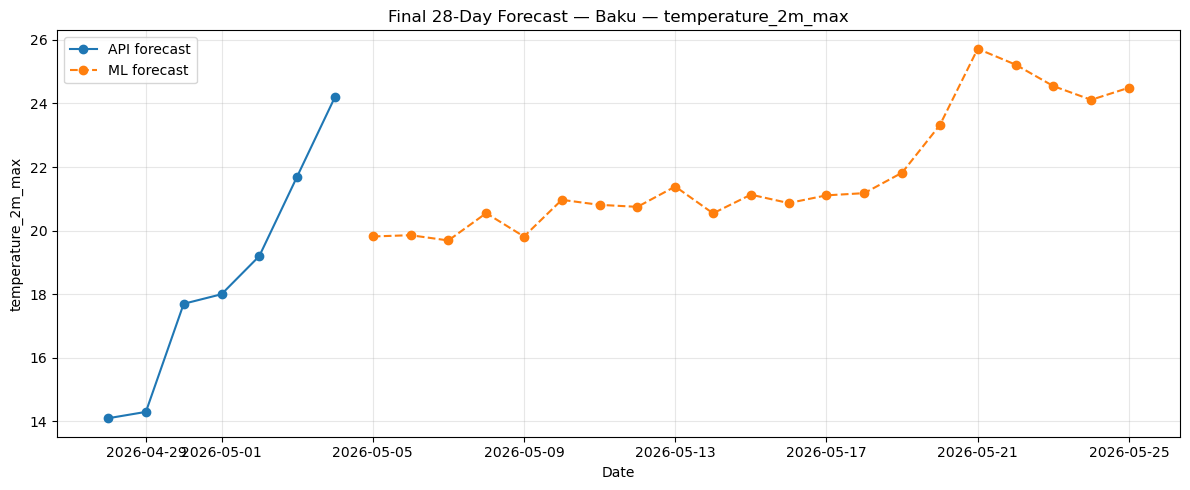

In [25]:
plot_final_forecast(
    forecast_df=final_28d_forecast,
    city="Baku",
    target="temperature_2m_max",
)

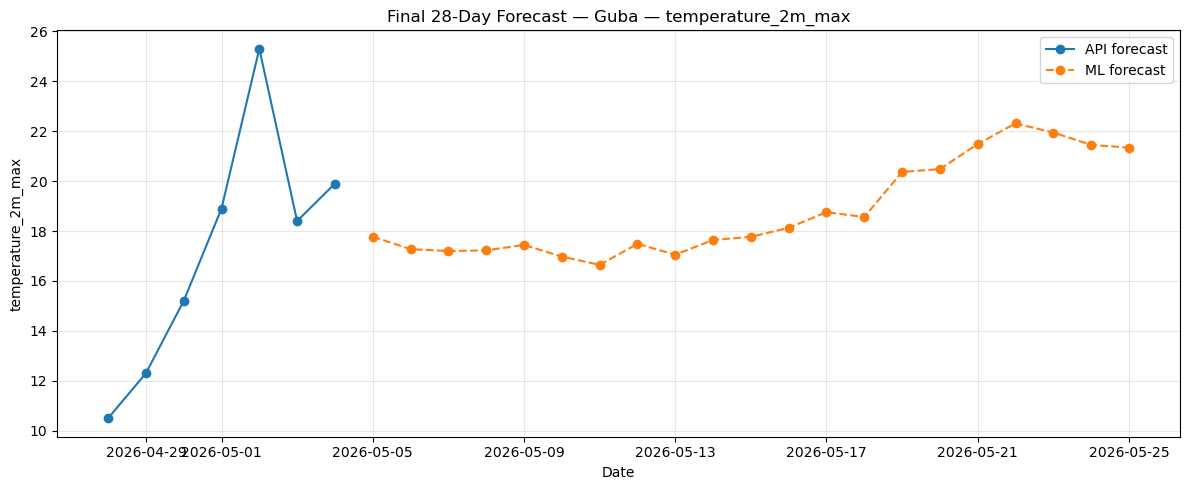

In [26]:
plot_final_forecast(
    forecast_df=final_28d_forecast,
    city="Guba",
    target="temperature_2m_max",
)

## 13. Save Forecast Output

In [27]:
with get_connection() as conn:
    conn.execute("CREATE SCHEMA IF NOT EXISTS analytics;")
    conn.register("final_28d_forecast_view", final_28d_forecast)

    conn.execute("""
        CREATE OR REPLACE TABLE analytics.final_28d_forecast AS
        SELECT * FROM final_28d_forecast_view;
    """)

print("analytics.final_28d_forecast table created.")

analytics.final_28d_forecast table created.


### 13.1 — Verify:

In [28]:
forecast_summary = run_query("""
SELECT
    MIN(target_time) AS min_date,
    MAX(target_time) AS max_date,
    COUNT(*) AS rows
FROM analytics.final_28d_forecast
""")

display(forecast_summary)

run_query("""
SELECT city, source, COUNT(*) AS rows
FROM analytics.final_28d_forecast
GROUP BY city, source
ORDER BY city, source
""")

,min_date,max_date,rows
0,2026-04-28,2026-05-25,140


,city,source,rows
0,Baku,api_forecast,7
1,Baku,ml_model,21
2,Gabala,api_forecast,7
3,Gabala,ml_model,21
4,Guba,api_forecast,7
5,Guba,ml_model,21
6,Lankaran,api_forecast,7
7,Lankaran,ml_model,21
8,Shaki,api_forecast,7
9,Shaki,ml_model,21


## 14. Modeling Summary

This notebook trained and evaluated several multi-output regression models for weather forecasting.

The models were tested on two forecast horizons:

- 7-day horizon
- 28-day horizon

The final model was selected using average RMSE across five target variables:

- maximum temperature
- precipitation
- wind speed
- relative humidity
- cloud cover

The final forecast uses a hybrid strategy:

- Days 1–7 are taken directly from the Open-Meteo Forecast API.
- Days 8–28 are predicted by the selected ML model.

The final output was saved into DuckDB as:

`analytics.final_28d_forecast`

This table can be used by the website, AI agent, and activity suitability layer.